# Using BHJet to study multi-wavelength observations of jetted systems 
We'll compare this first with observations of M87, and attempt to reproduce the SED. We'll then use observations for one X-ray binary system (GX 339-4) and compare these results. 

In [14]:
from pathlib import Path
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from bhjet import BHJet, BLJet, RadiationZone

def find_repository_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'tutorials' / 'tutorial_data').is_dir():
            return candidate

## 1. Choose the source and load the (provided) observations

For a new source, change `SOURCE_NAME` and `SOURCE_DIRECTORY` below. The data lives in `tutorials/tutorial_data/`, and this notebook expects a file named `<directory>/<directory>_dnde.csv`. The distance, redshift, viewing angle, and black-hole mass must also be updated. 

In [2]:
# --- Source settings: change these all together when starting with a new source ---
SOURCE_NAME = 'NGC 4261'
SOURCE_DIRECTORY = 'ngc4261'
DISTANCE_KPC = 29400 
REDSHIFT = 0.007465
VIEWING_ANGLE_DEG = 66.0
BLACK_HOLE_MASS_SOLAR = 5e8 #black hole mass in solar masses 

ERG_TO_EV = 6.242e11
EV_TO_ERG = 1.0 / ERG_TO_EV

repository_root = find_repository_root()
data_directory = repository_root / 'tutorials' / 'tutorial_data' / SOURCE_DIRECTORY
data_file = data_directory / f'{SOURCE_DIRECTORY}_dnde.csv'

## 2. Load and inspect the source SED

The table holds photon energy, differential photon flux, and its uncertainty. Astropy helps to keep the units explicit as we load and convert it to $E^2dN/dE$. (Not necessary for you to do anything with the units here, but here's [an overview](https://learn.astropy.org/tutorials/quantities.html) if you would like)

In [ ]:
data = Table.read(data_file, format='ascii.csv', delimiter=' ')
data['e_ref'].unit = u.eV
data['dnde'].unit = u.Unit('cm-2 s-1 eV-1')
data['dnde_err'].unit = u.Unit('cm-2 s-1 eV-1')

data_energy = data['e_ref'].quantity

data_sed = (
    data_energy.to(u.erg)**2 * data['dnde'].quantity.to('cm-2 s-1 erg-1')
).to('erg cm-2 s-1')

data_sed_error = (
    data_energy.to(u.erg)**2 * data['dnde_err'].quantity.to('cm-2 s-1 erg-1')
).to('erg cm-2 s-1')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(data_energy.to_value(u.eV), data_sed.value, yerr=data_sed_error.value,
            fmt='o', ms=4, label=SOURCE_NAME)
ax.set(xscale='log', yscale='log', xlabel='Observed energy [eV]',
       ylabel=r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]')
ax.legend();

In [9]:
energy_eV = np.geomspace(1e-9, 1e11, 200)

MULTI_ZONE_PARAMETERS = {
    'jet_power_eddington': 2e-4,
    'r_initial': 9.0,
    'z_end_of_acceleration': 100.0,
    'z_dissipation': 100.0,
    'sigma_final': 0.1,
    'gamma_final': 2.1,
    'electron_temperature_jet_base': 500.0,
    'fraction_nonthermal_electrons': 0.5,
    'factor_break_electrons': 0.1,
    'factor_max_energy_electrons': 8e-9,
    'index_injected_electrons': 1.75,
    'plasma_beta_jet_base': 0.02, 
    'dlgz': 0.1, 
}

def calculate_multi_zone_sed(parameters, energy_grid_eV=energy_eV):
    dynamics = BLJet(
        mass_bh=BLACK_HOLE_MASS_SOLAR,
        z_jet_launching=2.0, z_max_calculation=1e6,
        gamma_acceleration_exponent=0.2, opening_angle_constant=0.15,
        fraction_nonthermal_protons=0.1, factor_break_protons=1.0,
        factor_max_energy_protons=1.0, index_injected_protons=2.0,
        verbosity_level=0, **parameters,
    )
    jet = BHJet(
        theta_obs=VIEWING_ANGLE_DEG, distance=DISTANCE_KPC, redshift=REDSHIFT,
        include_counterjet=True, compton_threshold=1e-5,
        profile_time=False, verbosity_level=0,
    )
    jet.init_jet_dynamics(dynamics)
    jet.compute_full_jet(photon_energy_grid=(energy_grid_eV * EV_TO_ERG).tolist())
    model_sed = energy_grid_eV * EV_TO_ERG * np.asarray(
        jet.get_observed_photon_flux_total(), dtype=float
    )
    return dynamics, jet, model_sed

dynamics, multi_zone_jet, multi_zone_sed = calculate_multi_zone_sed(MULTI_ZONE_PARAMETERS)
print(f'Multi-zone model: {dynamics.n_zones} radiation zones')

Multi-zone model: 56 radiation zones


In [10]:
FIT_PARAMETERS = MULTI_ZONE_PARAMETERS.copy()
FIT_PARAMETERS.update({
    'jet_power_eddington': 2e-3,
    'z_dissipation': 100.0,
    'electron_temperature_jet_base': 500.0,
    'factor_max_energy_electrons': 8e-9,
    'index_injected_electrons': 1.75,
    'z_end_of_acceleration': 1e4
})

fit_dynamics, fit_jet, fit_sed = calculate_multi_zone_sed(FIT_PARAMETERS)

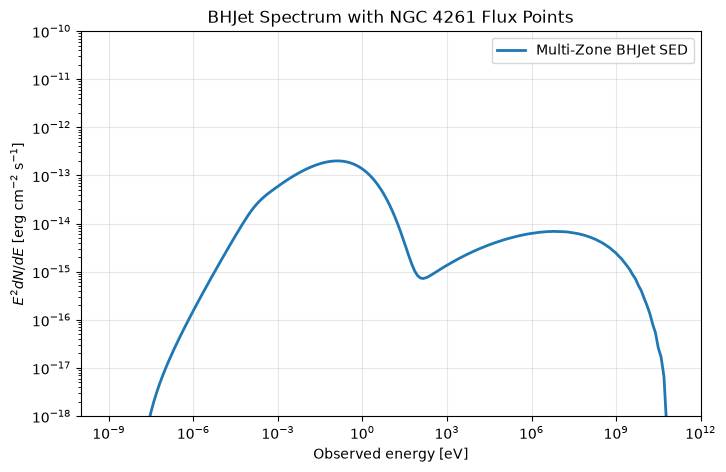

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
# ax.errorbar(data_energy.to_value(u.eV), data_sed.value, yerr=data_sed_error.value, fmt='o', ms=4,
#             color='black', label=f'{SOURCE_NAME} data')

ax.loglog(energy_eV, multi_zone_sed, lw=2, label='Multi-Zone BHJet SED')
ax.set(xlabel='Observed energy [eV]', ylabel=r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]',
       title=f'BHJet Spectrum with {SOURCE_NAME} Flux Points')
ax.set_ylim(1e-18, 1e-10)
ax.grid(alpha=0.3)
ax.legend();

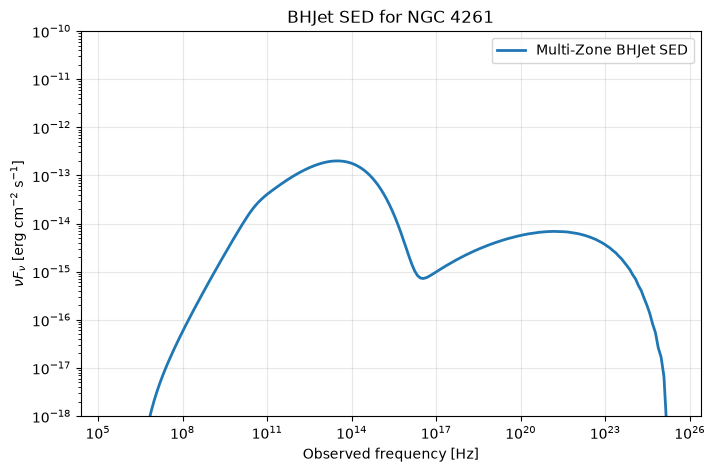

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

# data_frequency_hz = data_energy.to_value(u.Hz, equivalencies=u.spectral())
fit_frequency_hz = (energy_eV * u.eV).to_value(u.Hz, equivalencies=u.spectral())

# fig, ax = plt.subplots(figsize=(8, 5))
# ax.errorbar(data_frequency_hz, data_sed.value, yerr=data_sed_error.value,
#             fmt='o', ms=4, color='black', label=f'{SOURCE_NAME} data')

ax.loglog(fit_frequency_hz, multi_zone_sed, lw=2, label='Multi-Zone BHJet SED')
ax.set(xscale='log', yscale='log', xlabel='Observed frequency [Hz]',
       ylabel=r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]',
       title=f'BHJet SED for {SOURCE_NAME}')
ax.grid(alpha=0.3)
ax.set_ylim(1e-18, 1e-10)
ax.legend();